# Linear Regression on Network Traffic

In this hands-on assignment, we will explore learn models, in particular linear regression. Linear models can work well when there is a linear relationship between the target variable being predicted and the input features. In other words, when the target prediction can be modeled as a linear combination of the input features, linear models may be appropriate.

We'll explore the relationship beween bytes and packets in this hands-on, which may have a linear relationship at times. We will also explore how basis expansion---in particular polynomial basis expansion---can allow linear regression to fit more complex relationships between features and targets.

In [1]:
# Machine Learning Libraries
import numpy as np
import pandas as pd
from sklearn import linear_model

import logging
logging.getLogger("scapy.runtime").setLevel(logging.ERROR)

# Plotting Library
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams["figure.figsize"] = (8,6)

### Local copy of `netml`'s PCAP parser (with a library modification)

The `STATS` feature set that `netml` computes for each flow (duration, packets/sec,
bytes/sec, mean/median/std packet size, quartiles, min, max) does **not** include the
raw *number of packets per flow* or *number of bytes per flow* — only their per-second
*rates*. To get those two totals as features, `netml`'s `parser.py` has to be modified
(see the [reference PR](https://github.com/chicago-cdac/netml/pull/16/commits/79c0f930f2882c7bf042a9eb45e2a6ac413a695d)),
adding `num_pkts` and `num_bytes` to the `base_features` list built in `_get_STATS`.

Rather than editing the installed `netml` package on disk, the entire contents of
`netml/pparser/parser.py` (plus the couple of helper functions it imports from
`netml/utils/tool.py`) are pasted into the next cell **as-is, with that one modification
applied**, so the change is self-contained in this notebook. The `PCAP` class defined
below shadows the one from the installed library for the rest of this notebook.

In [2]:
"""PCAP parser (copied from netml/pparser/parser.py, modified in this notebook)

'pparser' parses pcaps to flow features by Scapy.

MODIFICATION: `_get_STATS()` below appends `num_pkts` and `num_bytes` to
`base_features`, so the STATS feature vector carries "number of packets per flow"
and "number of bytes per flow" in addition to the original duration/rate/size-quantile
features. That's the only change relative to the upstream file; everything else is
an unmodified copy so that `PCAP` behaves exactly like the library version otherwise.
"""
import ipaddress
import os
import pickle
import time
from collections import OrderedDict
from datetime import datetime
from functools import wraps

import netaddr
import numpy as np
import pandas as pd

#
# FIXME: 'import *' bad for a number of reasons...
#
# For one: the below imports class 'datetime.datetime' and invalidates our import of the module.
#
# (So for now we'll import the class datetime.datetime as well.)
#
from scapy.all import *

from scapy.layers.inet import IP, TCP, UDP


# ---------------------------------------------------------------------------
# helpers normally imported from netml/utils/tool.py
# ---------------------------------------------------------------------------

def check_path(file_path, overwrite=True):
    """Check if a path is existed or not.
     If the path doesn't exist, then create it.
    """
    path_dir = os.path.dirname(file_path)
    if not os.path.exists(path_dir) and len(path_dir) > 0:
        os.makedirs(path_dir)

    if os.path.exists(file_path):
        if overwrite:
            os.remove(file_path)

    return file_path


def dump_data(data, out_file, verbose=True):
    """Save data to pickle file"""
    # won't close descriptor we don't open
    try:
        out_desc = None  # avoid UnboundLocalError in finally

        if hasattr(out_file, 'write'):
            out_desc = out_file
        elif out_file:
            # FIXME: overwrite=verbose?
            check_path(out_file, overwrite=verbose)
            out_desc = open(out_file, 'wb')
        else:
            raise TypeError("out_file argument required")

        pickle.dump(data, out_desc)
    finally:
        if out_desc is not None and out_desc is not out_file:
            # it's ours to manage
            out_desc.close()


def load_data(in_file):
    """load data from pickle file"""
    try:
        in_desc = None  # avoid UnboundLocalError in finally

        if hasattr(in_file, 'read'):
            in_desc = in_file
        else:
            in_desc = open(in_file, 'rb')

        return pickle.load(in_desc)
    finally:
        if in_desc is not None and in_desc is not in_file:
            in_desc.close()


def data_info(data=None, name='data'):
    """Print data basic information"""

    pd.set_option('display.max_rows', 500)
    pd.set_option('display.max_columns', 500)
    pd.set_option('display.width', 100)
    pd.set_option('display.float_format', lambda x: '%.3f' % x)  # without scientific notation

    columns = ['col_' + str(i) for i in range(data.shape[1])]
    dataset = pd.DataFrame(data=data, index=range(data.shape[0]), columns=columns)
    print(f'{name}.shape: {data.shape}')
    print(dataset.describe())
    print(dataset.info(verbose=True))


def timing(func):
    """Calculate the execute time of the given func"""

    @wraps(func)
    def wrapper(*args, **kwargs):
        verbose = kwargs.get('verbose', 0)
        start = time.time()
        st = datetime.fromtimestamp(start).strftime('%Y-%m-%d %H:%M:%S')
        if verbose:
            print(f'\'{func.__name__}()\' starts at {st}')
        result = func(*args, **kwargs)
        end = time.time()
        ed = datetime.fromtimestamp(end).strftime('%Y-%m-%d %H:%M:%S')
        tot_time = (end - start) / 60
        tot_time = float(f'{tot_time:.4f}')
        if verbose:
            print(f'\'{func.__name__}()\' ends at {ed} and takes {tot_time} mins.')
        func.tot_time = tot_time  # add new variable to func
        return result, tot_time

    return wrapper


# ---------------------------------------------------------------------------
# netml/pparser/parser.py
# ---------------------------------------------------------------------------

def _get_fid(pkt):
    """Extract fid (five-tuple) from a packet: only focus on IPv4
    Parameters
    ----------

    Returns
    -------
        fid: five-tuple
    """

    if IP in pkt and TCP in pkt:
        # flow_type = 'TCP'
        fid = (pkt[IP].src, pkt[IP].dst, pkt[TCP].sport, pkt[TCP].dport, 6)
    elif IP in pkt and UDP in pkt:
        # flow_type = 'UDP'
        fid = (pkt[IP].src, pkt[IP].dst, pkt[UDP].sport, pkt[UDP].dport, 17)
    else:  # others
        fid = ('', '', -1, -1, -1)

    return fid


def _get_frame_time(pkt):
    """Get packet arrival time

    Parameters
    ----------
    pkt:
        a packet
    Returns
    -------
        pkt_time: float
    """
    return float(pkt.time)


def _get_flow_duration(pkts):
    """Get flow duration

    Parameters
    ----------
    pkts: list
        a list of packets of a flow
    Returns
    -------
        flow_duration: float
    """
    pkt_times = [_get_frame_time(pkt) for pkt in pkts]
    flow_duration = max(pkt_times) - min(pkt_times)
    return flow_duration


def _pcap2flows(pcap_file, flow_pkts_thres=2, *, tcp_timeout=600, udp_timeout=600, verbose=0):
    """Extract flows. Only keep TCP and UDP flows, others are discarded.

    Parameters
    ----------
    pcap_file: str
        a pcap needed to processed.

    flow_pkts_thres: int (default is 2)
        the minimum number of packets of each flow is to control which flow should be kept
        and which one should be discarded. The default value is 2, i.e., all the flows which have less than 2 packets
        are discarded. It must be >= 2.

    tcp_timeout: int (default is 600s)
        a timeout is to split flow

    ucp_timeout: int (default is 600s)
        a timeout is to split flow

    verbose: int (default is 0)
        a print level is to control what information should be printed according to the given value.
        The higher the value is, the more info is printed.

    Returns
    -------
        flows: list

    """

    if verbose:
        print(f'pcap_file: {pcap_file}')

    # store all extracted flows into a dictionary, whose key is flow id ('fid': five-tuple) and value is packtes
    # that belongs to the flow.
    flows = OrderedDict()
    try:
        # iteratively get each packet from the pcap
        for i, pkt in enumerate(PcapReader(pcap_file)):
            if (verbose > 3) and (i % 10000 == 0):
                print(f'ith_packets: {i}')

            if (TCP in pkt) or (UDP in pkt):

                # this function treats bidirection flows as two sessions (hereafter, we use sessions
                # and flows interchangeably).
                fid = _get_fid(pkt)

                if fid not in flows.keys():
                    flows[fid] = [pkt]
                else:
                    flows[fid].append(pkt)
            else:
                continue

    except Exception as e:
        msg = f'Parse PCAP error: {e}!'
        raise RuntimeError(msg)

    if verbose > 3:
        print(f'len(flows): {len(flows.keys())}')

    # split flows by TIMEOUT and discard flows that have less than "flow_pkts_thres" packets.
    n_pkts = 0
    new_flows = []  # store the preprocessed flows
    for i, (fid, pkts) in enumerate(flows.items()):
        n_pkts += len(pkts)
        if len(pkts) < max(2, flow_pkts_thres):
            # discard flows that have less than "max(2, flow_pkts_thres)" packets
            continue

        # Is it necessary to sort packets by arrival_times?
        pkts = sorted(pkts, key=_get_frame_time, reverse=False)

        subflows = []
        # split flows by TIMEOUT
        for j, pkt in enumerate(pkts):
            pkt_time = _get_frame_time(pkt)
            if j == 0:
                subflow_tmp = [pkt]
                split_flow = False  # if a flow is not split with interval, label it as False, otherwise, True
                continue
            # print(fid, pkt)
            if (6 in fid) or (TCP in pkt):
                # handle TCP packets, TCP is 6
                # a timeout (the idle time) is the duration between the previous pkt and the current one.
                if pkt_time - _get_frame_time(subflow_tmp[-1]) > tcp_timeout:
                    # Note: here subflow_tmp will only have 1 packet
                    subflows.append((fid, subflow_tmp))
                    subflow_tmp = [pkt]  # create a new subflow and store the current packet as the first packet of it.
                    split_flow = True
                else:
                    subflow_tmp.append(pkt)
            elif (17 in fid) or UDP in pkt:
                # handle UDP packets, UDP is 17
                if pkt_time - _get_frame_time(subflow_tmp[-1]) > udp_timeout:
                    # print(fid, len(subflow_tmp))
                    # Note: here subflow_tmp will only have 1 packet
                    # E.g., without timeout splitting, the flow has two packets, pkt1 (time=2020-08-06 11:01:20.029699)
                    # and pkt2 (time=2020-08-07 01:01:20.376141), so after timeout splitting, subflow_tmp = [pkt1]
                    # (only one packet)
                    subflows.append((fid, subflow_tmp))
                    subflow_tmp = [pkt]
                    split_flow = True
                else:
                    subflow_tmp.append(pkt)
            else:  # it's not possible, because flows only include TCP and UDP flows
                pass

        # if the current flow is not split by TIMEOUT, then add it into subflows
        if not split_flow:
            subflows.append((fid, subflow_tmp))
        else:
            # discard the last subflow_tmp
            pass

        new_flows.extend(subflows)

    new_flows = [(fid, pkts) for (fid, pkts) in new_flows if len(pkts) >= flow_pkts_thres]
    if verbose > 3:
        n_lt_2 = len([len(pkts) for fid, pkts in flows.items() if len(pkts) < flow_pkts_thres])
        n_gt_2 = len([len(pkts) for fid, pkts in flows.items() if len(pkts) >= flow_pkts_thres])
        print(f'total number of flows: {len(flows.keys())}. Num of flows < {flow_pkts_thres} pkts: {n_lt_2}, '
              f'and >={flow_pkts_thres} pkts: {n_gt_2} without timeout splitting.')
        print(
            f'kept flows: {len(new_flows)}. Each of them has at least {flow_pkts_thres} pkts after timeout splitting.')

    return new_flows


def _flows2subflows(flows, interval=10, *, flow_pkts_thres=2, verbose=0):
    """Split flows to subflows by interval

    Parameters
    ----------
    flows: list
      all flows needed to be split

    interval: float (default is 5.0s)
       a window is to split each flow

    flow_ptks_thres: int (default is 2)
        the minimum number of packets of each flow is to control which flow should be kept
        and which one should be discarded. The default value is 2, i.e., all the flows which have less than 2 packets
        are discarded. It must be >= 2.

    verbose: int (default is 0)
        a print level is to control what information should be printed according to the given value.
        The higher the value is, the more info is printed.

    Returns
    -------
    subflows: list
        each of subflow has at least "flow_ptks_thres" packets
    """

    new_flows = []  # store all subflows
    for i, (fid, pkts) in enumerate(flows):
        if (verbose > 3) and (i % 1000) == 0:
            print(f'{i}th_flow: len(pkts): {len(pkts)}')

        # Is it necessary to sort packets by arrival_times ?
        pkts = sorted(pkts, key=_get_frame_time, reverse=False)

        subflows = []
        # split flows by interval
        for j, pkt in enumerate(pkts):
            pkt_time = _get_frame_time(pkt)
            if j == 0:
                subflow_tmp_start_time = pkt_time
                subflow_tmp = [(subflow_tmp_start_time, pkt)]
                split_flow = False  # if a flow is not split with interval, label it as False, otherwise, True
                continue

            if (6 in fid) or (TCP in pkt):
                # handle TCP packets, TCP is 6
                # a timeout (the idle time) is the duration between the previous pkt and the current one.
                if pkt_time - subflow_tmp[-1][0] > interval:
                    subflows.append((fid, subflow_tmp))
                    subflow_tmp_start_time += int((pkt_time - subflow_tmp_start_time) // interval) * interval
                    # create a new subflow and store "subflow_tmp_start_time" as the time. Here, it will has a tiny
                    # difference of packet time between "subflow_tmp_start_time" and the current packet time.
                    subflow_tmp = [(subflow_tmp_start_time, pkt)]
                    split_flow = True
                else:
                    subflow_tmp.append((pkt_time, pkt))

            elif (17 in fid) or UDP in pkt:
                # handle UDP packets, UDP is 17
                if pkt_time - subflow_tmp[-1][0] > interval:
                    subflows.append((fid, subflow_tmp))
                    subflow_tmp_start_time += int((pkt_time - subflow_tmp_start_time) // interval) * interval
                    subflow_tmp = [(subflow_tmp_start_time, pkt)]
                    split_flow = True
                else:
                    subflow_tmp.append((pkt_time, pkt))
            else:  # it's not possible, because flows only include TCP and UDP flows
                pass

        # if the current flow is not split by interval, then add it into subflows
        if not split_flow:
            subflows.append([fid, subflow_tmp])
        else:
            # discard the last subflow_tmp
            pass

        new_flows.extend(subflows)

    # sort all flows by packet arrival time, each flow must have at least two packets
    subflows = []
    for fid, subflow_tmp in new_flows:
        if len(subflow_tmp) < max(2, flow_pkts_thres):
            continue
        subflows.append((fid, [pkt for pkt_time, pkt in subflow_tmp]))

    new_flows = subflows
    if verbose > 1:
        print(f'After splitting flows, the number of subflows: {len(new_flows)} and each of them has at least '
              f'{flow_pkts_thres} packets.')

    return new_flows


def _get_header_features(flows):
    """Extract header features which includes TCP Flags and TTL
    Parameters
    ----------

    Returns
    -------
       headers: a list
    """

    def _parse_tcp_flgs(tcp_flgs):
        # flags = {
        #     'F': 'FIN',
        #     'S': 'SYN',
        #     'R': 'RST',
        #     'P': 'PSH',
        #     'A': 'ACK',
        #     'U': 'URG',
        #     'E': 'ECE',
        #     'C': 'CWR',
        # }
        flgs = {
            'F': 0,
            'S': 0,
            'R': 0,
            'P': 0,
            'A': 0,
            'U': 0,
            'E': 0,
            'C': 0,
        }

        for flg in tcp_flgs:
            if flg in flgs.keys():
                flgs[flg] += 1

        return list(flgs.values())

    features = []
    for fid, pkts in flows:
        flgs_lst = np.zeros((8, 1))  # 8 TCP flags
        header_features = []
        for i, pkt in enumerate(pkts):
            if pkt.payload.proto == 6:  # tcp
                flgs_lst += np.asarray(_parse_tcp_flgs(pkt.payload.payload.flags)).reshape(-1, 1)  # parses tcp.flgs
            header_features.append(pkt.payload.ttl)

        features.append(list(flgs_lst.flatten()) + header_features)

    return features


def _get_IAT(flows):
    """Extract interarrival times (IAT) features  from flows.
    Parameters
    ----------

    Returns
    -------
    features: a list
        iats
    fids: a list
        each value is five-tuple
    """
    features = []
    fids = []
    for fid, pkts in flows:
        pkt_times = [_get_frame_time(pkt) for pkt in pkts]
        # some packets have the same time, please double check the pcap.
        iats = list(np.diff(pkt_times))
        features.append(iats)
        fids.append(fid)

    return features, fids


def _get_SIZE(flows):
    """Extract packet sizes features from flows
    Parameters
    ----------

    Returns
    -------
    features: a list
        sizes
    fids: a list
        each value is five-tuple
    """

    features = []
    fids = []
    for fid, pkts in flows:
        sizes = [len(pkt) for pkt in pkts]
        features.append(sizes)
        fids.append(fid)

    return features, fids


def _get_IAT_SIZE(flows):
    """Extract iats and sizes features from flows
    Parameters
    ----------

    Returns
    -------
    features: a list
        iats_sizes
    fids: a list
        each value is five-tuple
    """

    features = []
    fids = []
    for fid, pkts in flows:
        pkt_times = [_get_frame_time(pkt) for pkt in pkts]
        iats = list(np.diff(pkt_times))
        sizes = [len(pkt) for pkt in pkts]
        iats_sizes = []
        for j in range(len(iats)):
            iats_sizes.extend([iats[j], sizes[j]])
        iats_sizes.append(sizes[-1])
        features.append(iats_sizes)
        fids.append(fid)

    return features, fids


def _get_STATS(flows):
    """get basic stats features, which includes duration, pkts_rate, bytes_rate, mean,
    median, std, q1, q2, q3, min, max, and (NEW) num_pkts and num_bytes.

    Parameters
    ----------
    flows:

    Returns
    -------
    features: a list
        stats
    fids: a list
        each value is five-tuple
    """

    features = []
    fids = []
    for fid, pkts in flows:
        sizes = [len(pkt) for pkt in pkts]

        sub_duration = _get_flow_duration(pkts)
        num_pkts = len(sizes)  # number of packets in the flow
        num_bytes = sum(sizes)  # all bytes in sub_duration  sum(len(pkt))
        if sub_duration == 0:
            pkts_rate = 0.0
            bytes_rate = 0.0
        else:
            pkts_rate = num_pkts / sub_duration  # it will be very larger due to the very small sub_duration
            bytes_rate = num_bytes / sub_duration

        q1, q2, q3 = np.quantile(sizes, q=[0.25, 0.5, 0.75])  # q should be [0,1] and q2 is np.median(data)
        # <-- MODIFICATION: append num_pkts and num_bytes so each flow's total packet
        #     count and byte count are available as features, not just their rates.
        base_features = [sub_duration, pkts_rate, bytes_rate, np.mean(sizes), np.std(sizes),
                         q1, q2, q3, np.min(sizes), np.max(sizes), num_pkts, num_bytes]

        features.append(base_features)

        fids.append(fid)

    return features, fids


def _get_SAMP(flows, sampling_feature='SAMP_NUM', sampling_rate=0.1, verbose=0):
    """Extract sampling IATs from subwindows obtained by splitting each flow.

    For example, sampling_feature = 'SAMP_NUM'
        The length in time of the sub window is what we’re calling sampling rate.
           features obtained on sampling_rate = 0.1 means that:
            1) split each flow into small windows, each window has 0.1 duration (the length in time of each small window)
            2) obtain the number of packets from each window (0.1s).
            3) all the values obtained form each window make up of the features (SAMP_NUM).

    Parameters
    ----------
    flows: list
        all flows.

    sampling_feature: str
        'SAMP_NUM' or 'SAMP_SIZE'
        the feature we wants to extract from each flow.

    sampling_rate: float
        the duration of the window

    Returns
    -------

    features: a list
       SAMP features

    fids: a list
        each value is five-tuple

    """
    features = []
    fids = []
    for fid, pkts in flows:
        # for each flow
        each_flow_features = []
        pkt_times = [_get_frame_time(pkt) for pkt in pkts]
        pkt_sizes = [len(pkt) for pkt in pkts]
        samp_sub = -1
        for i in range(len(pkts)):
            if i == 0:
                current = pkt_times[0]
                if sampling_feature == 'SAMP_NUM':
                    samp_sub = 1
                elif sampling_feature == 'SAMP_SIZE':
                    samp_sub = pkt_sizes[0]
                continue
            if pkt_times[i] - current <= sampling_rate:  # interval
                if sampling_feature == 'SAMP_NUM':
                    samp_sub += 1
                elif sampling_feature == 'SAMP_SIZE':
                    samp_sub += pkt_sizes[i]
                else:
                    print(f'{sampling_feature} is not implemented yet')
            else:  # if times[i]-current > sampling_rate:    # interval
                current += sampling_rate
                each_flow_features.append(samp_sub)
                # the time diff between times[i] and times[i-1] will be larger than mutli-samplings
                # for example, times[i]=10.0s, times[i-1]=2.0s, sampling=0.1,
                # for this case, we should insert int((10.0-2.0)//0.1) * [0]
                num_intervals = int(np.floor((pkt_times[i] - current) // sampling_rate))
                if num_intervals > 0:
                    num_intervals = min(num_intervals, 500)
                    each_flow_features.extend([0] * num_intervals)
                    current += num_intervals * sampling_rate
                if len(each_flow_features) > 500:  # avoid num_features too large to excess the memory.
                    # return fid, each_flow_features[:500]
                    samp_sub = -1
                    each_flow_features = each_flow_features[:500]
                    break

                if sampling_feature == 'SAMP_NUM':
                    samp_sub = 1
                elif sampling_feature == 'SAMP_SIZE':
                    samp_sub = pkt_sizes[i]

        if samp_sub > 0:  # handle the last sub period in the flow.
            each_flow_features.append(samp_sub)

        features.append(each_flow_features)
        fids.append(fid)

    # if verbose:
    #     show_len = 10  # only show the first 20 difference
    #     samp_lens = np.asarray([len(samp_features) for samp_features in features])[:show_len]

    return features, fids


def _get_SAMP_NUM(flows, sampling_rate=1):
    """Extract sampling the number of packets from subwindows obtained by splitting each flow.

     The length in time of the sub window is what we’re calling sampling rate.
        features obtained on sampling_rate = 0.1 means that:
         1) split each flow into small windows, each window has 0.1 duration (the length in time of each small window)
         2) obtain the number of packets from each window (0.1s).
         3) all values obtained from each window make up of the features (SAMP_NUM).

    Parameters
    ----------
        flows: list

        sampling_rate: float
           the duration of subwindow (interval)
    Returns
    -------
    features: a list
        sizes
    fids: a list
        each value is five-tuple
    """

    features, fids = _get_SAMP(flows, sampling_feature='SAMP_NUM', sampling_rate=sampling_rate)

    return features, fids


def _get_SAMP_SIZE(flows, sampling_rate=1):
    """Extract sampling total sizes of packets from each subwindow after splitting each flow.

     The length in time of the subwindow is what we’re calling sampling rate.
        features obtained on sampling_rate = 0.1 means that:
         1) split each flow into small windows, each window has 0.1 duration (the length in time of each small window)
         2) obtain the total size of packets in each window (0.1s).
         3) all the values obtained from each window make up of the features (SAMP_SIZE).

    Parameters
    ----------
        flows:list

        sampling_rate: float
           the duration of subwindow (interval)

    Returns
    -------
    features: a list
        sizes
    fids: a list
        each value is five-tuple
    """
    features, fids = _get_SAMP(flows, sampling_feature='SAMP_SIZE', sampling_rate=sampling_rate)

    return features, fids


def _get_split_interval(flow_durations, q_interval=0.9):
    interval = np.quantile(flow_durations, q=q_interval)

    return interval


def _get_FFT_data(features, fft_bin='', fft_part='real'):
    """Do fft transform of features

    Parameters
    ----------
    features: features

    fft_bin: int
        the dimension of transformed features
    fft_part: str
        'real' or 'real+imaginary' transformation

    Returns
    -------
    fft_features: a list
        transformed fft features
    """
    if fft_part == 'real':  # default
        fft_features = [list(np.real(np.fft.fft(v, n=fft_bin))) for v in features]

    elif fft_part == 'real+imaginary':
        msg = f'{fft_part}'
        raise NotImplementedError(msg)

    else:
        msg = f'fft_part: {fft_part} is not correct, please modify it and retry!'
        raise ValueError(msg)

    return fft_features


class PCAP:

    def __init__(self, pcap_file, *, flow_ptks_thres=2, verbose=0, random_state=42):
        """PCAP includes all processing functions of pcaps, such as pcap2flows, flow2features, and label_flows .

        Parameters
        ----------
        pcap_file: str
            a pcap needed to processed.

        flow_ptks_thres: int (default is 2)
            the minimum number of packets of each flow is to control which flow should be kept
            and which one should be discarded. The default value is 2, i.e., all the flows which have less than 2 packets
            are discarded. It must be >= 2.

        verbose: int (default is 0)
            a print level is to control what information should be printed according to the given value.
            The higher the value is, the more info is printed.

        random_state: int
            a value is to make your experiments more reproducible.

        Returns
        -------
            a PCAP instance

        """
        self.pcap_file = pcap_file
        self.flow_ptks_thres = flow_ptks_thres
        self.verbose = verbose
        self.random_state = random_state

        self.labels = None
        self.df = None

    @timing
    def _pcap2flows(self, interval=0, q_interval=0.1, *, tcp_timeout=600, udp_timeout=600):
        """Extract flows from the given pcap and split each flow to subflow by "interval" or "q_interval".
                   It prefers to choose "interval" as the split measure if interval > 0; otherwise, use q_interval to find an interval.
                    q_interval must be in [0, 1]

        Parameters
        ----------
        interval: float (default is 0.)
            an time interval is used to split a flow.

        q_interval: float (default is 0.9)
           a quntile (must be in [0, 1]) is to obtain "interval" from all flow durations.

        tcp_timeout: int (default is 600s)
            a value is to split flow by tcp_timeout.

        udp_timeout: int (default is 600s)
            a value is to split flow by udp_timeout.

        Returns
        -------
        all flows: list
            each element in the list represents a flow, and each flow includes 2 values: flow id (five-tuple) and packets.
        """

        # extract all flows firstly and then split flows to subflows
        flows = _pcap2flows(self.pcap_file, self.flow_ptks_thres, tcp_timeout=tcp_timeout, udp_timeout=udp_timeout,
                            verbose=self.verbose)

        if interval > 0:
            self.interval = interval
        else:
            if q_interval > 0:
                self.q_interval = q_interval

                self.flow_durations = [_get_flow_duration(pkts) for fid, pkts in flows]
                if self.verbose > 3:
                    data_info(np.asarray(self.flow_durations, dtype=float).reshape(-1, 1), name='flow_durations')
                self.interval = _get_split_interval(self.flow_durations, q_interval=self.q_interval)

            else:
                msg = f'q_interval must be in [0, 1]! Current q_interval is {q_interval}.'
                raise ValueError(msg)

        self.flows = _flows2subflows(flows, self.interval, flow_pkts_thres=self.flow_ptks_thres, verbose=self.verbose)

    def pcap2flows(self, interval=0.0, q_interval=0.9, *, tcp_timeout=600, udp_timeout=600):
        """Extract flows from the given pcap and split each flow to subflow by "interval" or "q_interval".
           It prefers to choose "interval" as the split measure if interval > 0; otherwise, use q_interval to find an interval.
            q_interval must be in [0, 1]

        Parameters
        ----------
        interval: float (default is 0.)
            an time interval is used to split a flow.

        q_interval: float (default is 0.9)
           a quntile (must be in [0, 1]) is to obtain "interval" from all flow durations.

        tcp_timeout: int (default is 600s)
            a value is to split flow by tcp_timeout.

        udp_timeout: int (default is 600s)
            a value is to split flow by udp_timeout.
        Returns
        -------
            self
        """
        _, tot_time = self._pcap2flows(interval, q_interval, tcp_timeout=tcp_timeout, udp_timeout=udp_timeout)
        self.pcap2flows.__dict__['tot_time'] = tot_time

    @timing
    def _flow2features(self, feat_type='IAT', *, fft=False, header=False):
        """Extract features from each flow according to feat_type, fft and header.

        Parameters
        ----------
        feat_type: str (default is 'IAT')
            which features do we want to extract from flows

        fft: boolean (default is False)
            if we need fft-features

        header: boolean (default is False)
            if we need header+features

        Returns
        -------
            self
        """
        self.feat_type = feat_type

        num_pkts = [len(pkts) for fid, pkts in self.flows]

        dim = int(np.floor(np.quantile(num_pkts, self.q_interval)))  # use the same q_interval to get the dimension

        if feat_type in ['IAT', 'FFT-IAT']:
            self.dim = dim - 1
            self.features, self.fids = _get_IAT(self.flows)
        elif feat_type in ['SIZE', 'FFT-SIZE']:
            self.dim = dim
            self.features, self.fids = _get_SIZE(self.flows)
        elif feat_type in ['IAT_SIZE', 'FFT-IAT_SIZE']:
            self.dim = 2 * dim - 1
            self.features, self.fids = _get_IAT_SIZE(self.flows)
        elif feat_type in ['STATS']:
            self.dim = 12
            self.features, self.fids = _get_STATS(self.flows)
        elif feat_type in ['SAMP_NUM', 'FFT-SAMP_NUM']:
            self.dim = dim - 1
            flow_durations = [_get_flow_duration(pkts) for fid, pkts in self.flows]
            # To obtain different samp_features, you should change q_interval ((0, 1))
            sampling_rate = _get_split_interval(flow_durations, q_interval=0.3)
            self.features, self.fids = _get_SAMP_NUM(self.flows, sampling_rate)
        elif feat_type in ['SAMP_SIZE', 'FFT-SAMP_SIZE']:
            self.dim = dim - 1  # here the dim of "SAMP_SIZE" is dim -1, which equals to the dimension of 'SAMP_NUM'
            flow_durations = [_get_flow_duration(pkts) for fid, pkts in self.flows]
            sampling_rate = _get_split_interval(flow_durations, q_interval=0.3)
            self.features, self.fids = _get_SAMP_SIZE(self.flows, sampling_rate)
        else:
            msg = f'feat_type ({feat_type}) is not correct! '
            raise ValueError(msg)

        if fft:
            self.features = _get_FFT_data(self.features, fft_bin=self.dim)
        else:
            # fix each flow to the same feature dimension (cut off the flow or append 0 to it)
            self.features = [v[:self.dim] if len(v) > self.dim else v + [0] * (self.dim - len(v)) for v in self.features]

        if header:
            _headers = _get_header_features(self.flows)
            h_dim = 8 + self.dim  # 8 TCP flags
            if fft:
                fft_headers = _get_FFT_data(_headers, fft_bin=h_dim)
                self.features = [h + f for h, f in zip(fft_headers, self.features)]
            else:
                # fix header dimension firstly
                headers = [h[:h_dim] if len(h) > h_dim else h + [0] * (h_dim - len(h)) for h in _headers]
                self.features = [h + f for h, f in zip(headers, self.features)]

        # change list to numpy array
        self.features = np.asarray(self.features, dtype=float)
        if self.verbose > 5:
            print(np.all(self.features >= 0))

    def flow2features(self, feat_type='IAT', *, fft=False, header=False):
        """Extract features from each flow according to feat_type, fft and header.

        Parameters
        ----------
        feat_type: str (default is 'IAT')
            which features do we want to extract from flows

        fft: boolean (default is False)
            if we need fft-features

        header: boolean (default is False)
            if we need header+features

        Returns
        -------
            self
        """
        _, tot_time = self._flow2features(feat_type, fft=fft, header=header)
        self.flow2features.__dict__['tot_time'] = tot_time

    @timing
    def _label_flows(self, label_file=None, label=0):
        """label each flow by label_file (only for CICIDS_2017 label_file) or label.
        If you want to parse other label file, you have to override "label_flows()" with your own one.
        (normal=0,and abnormal = 1)

        Parameters
        ----------
        label_file: str (path) or file
            a file that includes flow labels

        label: int
            if label_file is None, then use "label" to label each flow

        Returns
        -------
        self
        """

        if label_file:
            NORMAL_LABELS = [v.upper() for v in ['benign'.upper(), 'normal'.upper()]]

            # load CSV with pandas
            csv = pd.read_csv(label_file)

            true_labels = {}
            cnt_anomaly = 0
            cnt_nomral = 0

            for i, r in enumerate(csv.index):
                if (self.verbose > 3) and (i % 10000 == 0):
                    print(f"Label CSV {i}th row")
                row = csv.loc[r]
                fid = (str(row[" Source IP"]), str(row[" Destination IP"]), int(row[" Source Port"]),
                       int(row[" Destination Port"]), int(row[" Protocol"]))
                # ensure all 5-tuple flows have same label
                label_i = row[" Label"].upper()
                if label_i in NORMAL_LABELS:
                    label_i = 0
                    cnt_nomral += 1
                else:
                    label_i = 1
                    cnt_anomaly += 1

                # it will overwrite the previous label for the same fid.
                true_labels[fid] = label_i

            # label flows with ture_labels
            new_labels = []
            not_existed_fids = []
            new_flows = []
            for i, (fid, pkts) in enumerate(self.flows):
                if fid in true_labels.keys():
                    new_labels.append(true_labels[fid])
                    new_flows.append((fid, pkts))
                else:
                    # the fid does not exist in labels.csv
                    not_existed_fids.append(fid)
            if self.verbose > 3:
                print(
                    f'Number of labelled flows: {len(new_labels)}; number of not existed flows: {len(not_existed_fids)}')

            self.labels = new_labels
            self.flows = new_flows
        else:
            self.labels = [label] * len(self.flows)

        self.labels = np.asarray(self.labels, dtype=int)

    def label_flows(self, label_file=None, label=0):
        """label each flow by label_file (only for CICIDS_2017 label_file) or label.
        If you want to parse other label file, you have to override "label_flows()" with your own one.
        (normal=0,and abnormal = 1)

        Parameters
        ----------
        label_file: str (path) or file
            a file that includes flow labels

        label: int
            if label_file is None, then use "label" to label each flow

        Returns
        -------
        self
        """
        _, tot_time = self._label_flows(label_file, label)
        self.label_flows.__dict__['tot_time'] = tot_time

    _pcap_columns = (
        'time',
        'datetime',
        'length',
        'mac_dst',
        'mac_src',
        'ip_dst',
        'ip_src',
        'protocol',
        'port_dst',
        'port_src',
        'is_dns',
        'dns_query',
        'dns_resp',
    )

    def _iter_pcap_dict(self):
        """Stream extracted dict mappings from PCAP file.

        Requires:
          self.pcap_file: string filepath of PCAP file

        Returns:
          Iterator of dicts with one dict per packet in pcap file.

            The dicts have the following key/value pairs:

              "time"      : time the packet was receieved in seconds since epoch
              "datetime"  : time the packet was received as a datetime object
              "length"    : length of packet in bytes
              "mac_src"   : source MAC address
              "mac_dst"   : destination MAC address
              "ip_src"    : source IP address
              "ip_dst"    : destination IP address
              "protocol"  : 'TCP', 'UDP', 'ICMP', or None
              "port_src"  : source port
              "port_dst"  : destination port
              "is_dns"    : True if packet is DNS packet, else False
              "dns_query" : string DNS query
              "dns_resp"  : string DNS response

        """
        with PcapReader(self.pcap_file) as pcap_reader:
            for pkt in pcap_reader:
                pkt_dict = dict.fromkeys(self._pcap_columns)

                pkt_dict.update(
                    time=pkt.time,
                    datetime=datetime.fromtimestamp(int(pkt.time)),
                    length=len(pkt),
                    is_dns=False,
                )

                if Ether in pkt:
                    pkt_dict['mac_dst'] = pkt[Ether].dst
                    pkt_dict['mac_src'] = pkt[Ether].src

                if IP in pkt:
                    pkt_dict['ip_dst'] = pkt[IP].dst
                    pkt_dict['ip_src'] = pkt[IP].src

                if TCP in pkt:
                    pkt_dict['port_dst'] = pkt[TCP].dport
                    pkt_dict['port_src'] = pkt[TCP].sport
                    pkt_dict['protocol'] = 'TCP'
                elif UDP in pkt:
                    pkt_dict['port_dst'] = pkt[UDP].dport
                    pkt_dict['port_src'] = pkt[UDP].sport
                    pkt_dict['protocol'] = 'UDP'
                elif ICMP in pkt:
                    pkt_dict['protocol'] = 'ICMP'

                if (dnsqr := pkt.getlayer(DNSQR)) is not None:
                    pkt_dict.update(
                        is_dns=True,
                        dns_query=(
                            dnsqr.qname.decode('utf-8')
                            if isinstance(dnsqr.qname, bytes)
                            else dnsqr.qname,
                        )
                    )

                if (dnsrr := pkt.getlayer(DNSRR)) is not None:
                    pkt_dict.update(
                        is_dns=True,
                        dns_query=(
                            dnsrr.rrname.decode('utf-8')
                            if isinstance(dnsrr.rrname, bytes)
                            else dnsrr.rrname,
                        ),
                        dns_resp=(
                            dnsrr.rdata.decode('utf-8')
                            if isinstance(dnsrr.rdata, bytes)
                            else dnsrr.rdata,
                        )
                    )

                yield pkt_dict

    @timing
    def _pcap2pandas(self):
        """Parse PCAP file into pandas DataFrame.

        Requires:
            self.pcap_file: string filepath of PCAP file

        Returns:
          DataFrame with one packet per row.
            column names are those of _pcap_columns plus
            'ip_dst_int', 'ip_src_int', 'mac_dst_int', 'mac_dst_int'

        """
        self.df = pd.DataFrame(self._iter_pcap_dict(), columns=self._pcap_columns)

        self.df['datetime'] = pd.to_datetime(self.df['datetime'])

        self.df['ip_dst_int'] = self.df['ip_dst'].apply(
            lambda x: None if x is None else int(ipaddress.ip_address(x)))

        self.df['ip_src_int'] = self.df['ip_src'].apply(
            lambda x: None if x is None else int(ipaddress.ip_address(x)))

        self.df['mac_dst_int'] = self.df['mac_dst'].apply(
            lambda x: None if x is None else int(netaddr.EUI(x)))

        self.df['mac_src_int'] = self.df['mac_src'].apply(
            lambda x: None if x is None else int(netaddr.EUI(x)))

        self.df['time_normed'] = self.df['time'].apply(lambda x: x - self.df.iloc[0]['time'])

        self.df.sort_index(axis=1, inplace=True)

    def pcap2pandas(self):
        """Parse PCAP file into pandas DataFrame.

        Requires:
            self.pcap_file: string filepath of pcap file

        Sets:
            self.df

        """
        (_, self.pcap2pandas.__dict__['tot_time']) = self._pcap2pandas()


## Part 1: Simple Linear Regression.

### Group Traffic Info Flows 

This example below uses a packet capture that is provided in the repository. You are also welcome (and encouraged!) to capture your own traffic.

Use `netml` to load the pcap and convert packets to flows, using pcap2flows.

In [ ]:
hpcap = PCAP('data/http.pcap', flow_ptks_thres=2, verbose=10)
hpcap.pcap2flows()
len(hpcap.flows)

pcap_file: data/http.pcap
ith_packets: 0


ith_packets: 10000


ith_packets: 20000


len(flows): 593
total number of flows: 593. Num of flows < 2 pkts: 300, and >=2 pkts: 293 without timeout splitting.
kept flows: 293. Each of them has at least 2 pkts after timeout splitting.
flow_durations.shape: (293, 1)
        col_0
count 293.000
mean   11.629
std    15.820
min     0.000
25%     0.076
50%     0.455
75%    20.097
max    46.235
<class 'pandas.DataFrame'>
RangeIndex: 293 entries, 0 to 292
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   col_0   293 non-null    float64
dtypes: float64(1)
memory usage: 2.4 KB
None
0th_flow: len(pkts): 4
After splitting flows, the number of subflows: 291 and each of them has at least 2 packets.


291

### Generate Features

Use the `netml` "STATS" option to generate features for each flow, which will provide the following features for each flow:

0. Duration
1. Packets per second
2. Bytes per second
3. Mean packet size
4. Standard deviation of packet sizes
5. 25th, median, 75th, min, max packet sizes

By default, this does **not** include the total number of packets or total number of
bytes per flow — only their per-second rates. The exercise below requires a
[slight modification](https://github.com/chicago-cdac/netml/pull/16/commits/79c0f930f2882c7bf042a9eb45e2a6ac413a695d)
to the `netml` library (for versions <= 0.2.1) to add two additional features:
* number of packets per flow
* number of bytes per flow

Normally you'd modify the library (line 455 of `parser.py`) to add total number of
packets and bytes per flow. Since we shouldn't edit the installed library for this
notebook, that modification was made above instead: the `PCAP` class defined in this
notebook is a full copy of `netml`'s `parser.py` with `_get_STATS` changed to append
`num_pkts` and `num_bytes` to `base_features`. So `flow2features('STATS', ...)` below
already returns a 12-column feature matrix, with columns 10 and 11 being the number of
packets and number of bytes per flow, respectively.

In [ ]:
MINIMUM_PACKETS = 2

# HTTP requests -> benign traffic
http_pcap = PCAP('data/http.pcap', flow_ptks_thres=MINIMUM_PACKETS)
http_pcap.pcap2flows()
http_pcap.flow2features('STATS', fft=False, header=False)

In [9]:
print(http_pcap.features.shape)

# packets in flow
X = http_pcap.features[:, 10]
# bytes in flow
y = http_pcap.features[:, 11]

(291, 12)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,  random_state=42)

X_train = X_train.reshape(-1, 1)
X_test = X_test.reshape(-1, 1)


In [17]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### Train Model

Explore the relationship between some of these features. A natural one to explore is the relationship between the number of bytes in a flow and the number of packets in a flow.

Train a `Linear Regression` model from scikit learn to model this relationship, and output the resulting predictions into a vector `y_hat`.

In [18]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_train, y_train)

In [28]:
print(f"Train accuracy: {reg.score(X_train, y_train):.4f}")
print(f"Test accuracy: {reg.score(X_test, y_test):.4f}")

Train accuracy: 0.9915
Test accuracy: 0.9357


### A Caveat: The Acknowledgment-Packet Problem

Look closely at the scatter of bytes vs. packets before trusting the fit. Flows in a packet capture tend to fall into two populations: flows dominated by full-size data packets (around 1500 bytes each, e.g., downloads) and flows dominated by small acknowledgment (ACK) packets (a few tens of bytes each). A single line cannot describe both, since the "bytes per packet" slope differs by more than an order of magnitude between them.

Least squares makes this worse. The squared loss weights large residuals heavily, and the data-heavy flows have the largest byte counts and therefore the largest residuals. The fit chases those flows and largely ignores the ACK-heavy ones, which end up far from the line.

Some things to try:

1. **Log-transform** both bytes and packets before fitting, which compresses the range of the large flows so they no longer dominate the loss.
2. **Fit separate models** for the two populations (for example, split on mean packet size).
3. **Use a robust loss** such as `HuberRegressor` from `sklearn.linear_model`, which penalizes large residuals linearly rather than quadratically.

The cell below is a scaffold for the log-transform variant.

In [ ]:
from sklearn.linear_model import LinearRegression

# TODO: fit on log-transformed features and targets
# X_log = np.log1p(X)
# y_log = np.log1p(y)
# model_log = LinearRegression().fit(X_log, y_log)
# y_hat_log = np.expm1(model_log.predict(X_log))   # back to the original scale

# TODO: compare the error of this fit to the original fit (y_hat), on the original scale.
#       Which population of flows improved? Which got worse?

### Visualize Your Model

Plot the relationship that your model has learned, by plotting the learned model (which should be a line), along with the points.  Label your axes!

What do you notice about the relationship, and how it relates to the original points?

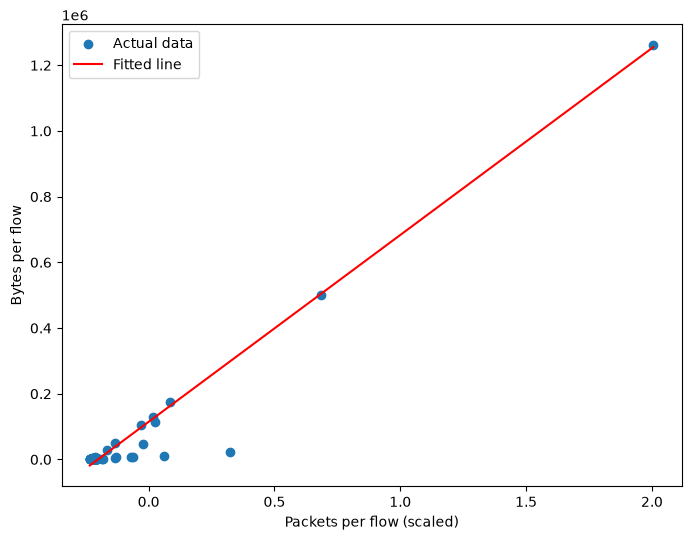

In [25]:
y_hat = reg.predict(X_test)

order = np.argsort(X_test[:, 0])

plt.scatter(X_test, y_test, label="Actual data")
plt.plot(X_test[order], y_hat[order], color="red", label="Fitted line")
plt.xlabel("Packets per flow (scaled)")
plt.ylabel("Bytes per flow")
plt.legend()
plt.show()

### Evaluation: Error Computation

In [27]:
from sklearn.metrics import mean_squared_error

print(f"RMSE (bytes): {mean_squared_error(y_test, y_hat) ** (1/2)}")

RMSE (bytes): 44374.08816633045


## Part 2: Polynomial Basis Expansion

Recall that one of the benefits of a polynomial feature expansion is that it is possible to fit a linear model to a resulting polynomial expansion of the features.

We will do that below.  Let's first create the regular features and then the polynomial expansion. You will need the `PolynomialFeatures` library from `sklearn.preprocessing`, as well as the `fit_transform` function to generate your feature expansion.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(2)

X_train = poly.fit_transform(X_train)
X_test = poly.transform(X_test)

Train the linear regression model on the expanded set of features, and generate a new set of predictions, `y_hat_poly`.

In [ ]:
reg = LinearRegression().fit(X_train, y_train)

print(f"Train accuracy: {reg.score(X_train, y_train):.4f}")
print(f"Test accuracy: {reg.score(X_test, y_test):.4f}")

y_hat_poly = reg.predict(X_test)

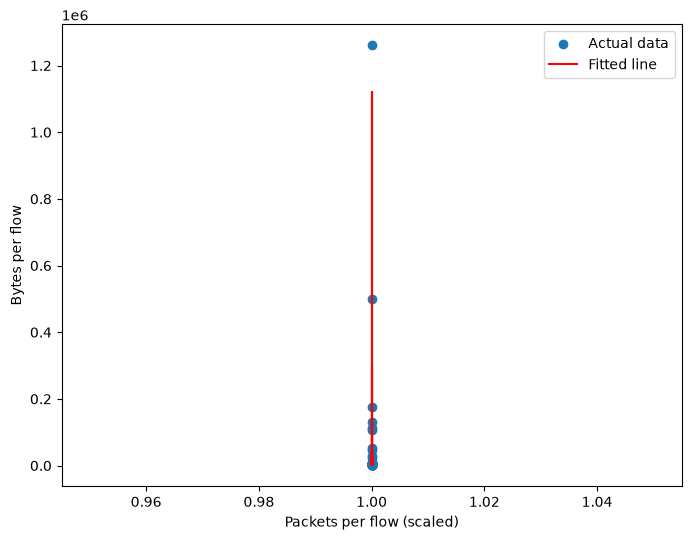

In [45]:
x_vals = X_test[:, 1]  # column 0 is the PolynomialFeatures bias term; column 1 is the original feature
order = np.argsort(x_vals)

plt.scatter(x_vals, y_test, label="Actual data")
plt.plot(x_vals[order], y_hat_poly[order], color="red", label="Fitted line")
plt.xlabel("Packets per flow (scaled)")
plt.ylabel("Bytes per flow")
plt.legend()
plt.show()

In [42]:
print(f"RMSE (bytes): {mean_squared_error(y_test, y_hat) ** (1/2)}")

RMSE (bytes): 44374.08816633045


## Part 3: Exploring Relationships between Other Features

In the earlier parts of this hands-on, we explored simple relationship between features and outcome variables. You can extend your analysis by exploring other relationships, such as the relationships between one or more of the features already output from `netml`.

## Bonus: Reducing Error on Test Set

In the above example, we used a polynomial basis expansion to reduce the error on the training set. But, we have no test set, so it is difficult to tell whether the model above is overfit to the training data.

In order for us to tell whether this model is a good fit, we need to test it on data that the model has not yet seen. This requires splitting the data into a training set and a test set.

A typical split between training data and test data might be 80% training data, 20% test data. You can also perform this process repeatedly and average the results. This process is called **cross-validation**.

### Part 1

1. Take a packet trace using wireshark and load it into the notebook.
2. Perform a simple linear regression fit and a fit with basis expansion (same as above), comparing errors.

The first two steps are the same as above, but you might try doing this for a larger sample so that your network traffic has more flows (i.e., data points).

### Part 2

3. Use functions from sklearn to split the data into training and testing. (train_test_split, or sklearn's CV function).
4. How does model accuracy compare for different polynomial basis expansions? (n=1, 2, 3, ?) At what point is the model overfit?
5. Can you experiment with a regularization parameter to control or reduce overfitting?